# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [5]:
corpus = """
deep learning is transforming artificial intelligence
deep learning is changing the future of technology
machine learning enables computers to learn from data
artificial intelligence powers modern applications
recurrent neural networks process sequential data
vanilla rnn struggles with long term dependencies
lstm solves the vanishing gradient problem
gru is a simplified version of lstm
text generation predicts the next word
language models generate meaningful sentences
deep neural networks require lots of data
data science combines statistics programming and machine learning
"""

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [7]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size :", total_words)

Vocabulary Size : 60


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [11]:
rnn_model = Sequential([
    Embedding(total_words, EMBEDDING_DIM, input_length=max_len - 1),
    SimpleRNN(UNITS),
    Dense(total_words, activation='softmax')
], name='VanillaRNN')

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_model.summary()

print("\n Training Vanilla RNN ...")
rnn_history = rnn_model.fit(X, y, epochs=EPOCHS, callbacks=[early_stop], verbose=0)
print(f" Done | Final loss: {rnn_history.history['loss'][-1]:.4f} "
      f"| Accuracy: {rnn_history.history['accuracy'][-1]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "VanillaRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


 Training Vanilla RNN ...
 Done | Final loss: 0.0777 | Accuracy: 0.9701


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [12]:
lstm_model = Sequential([
    Embedding(total_words, EMBEDDING_DIM, input_length=max_len - 1),
    LSTM(UNITS),
    Dense(total_words, activation='softmax')
], name='LSTM')

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_model.summary()

print("\n Training LSTM ...")
lstm_history = lstm_model.fit(X, y, epochs=EPOCHS, callbacks=[early_stop], verbose=0)
print(f" Done | Final loss: {lstm_history.history['loss'][-1]:.4f} "
      f"| Accuracy: {lstm_history.history['accuracy'][-1]:.4f}")

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


 Training LSTM ...
 Done | Final loss: 3.9896 | Accuracy: 0.1493


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [13]:
gru_model = Sequential([
    Embedding(total_words, EMBEDDING_DIM, input_length=max_len - 1),
    GRU(UNITS),
    Dense(total_words, activation='softmax')
], name='GRU')

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_model.summary()

print("\n Training GRU ...")
gru_history = gru_model.fit(X, y, epochs=EPOCHS, callbacks=[early_stop], verbose=0)
print(f" Done | Final loss: {gru_history.history['loss'][-1]:.4f} "
      f"| Accuracy: {gru_history.history['accuracy'][-1]:.4f}")

Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


 Training GRU ...
 Done | Final loss: 3.8795 | Accuracy: 0.0597


## 📉 Compare Training Loss

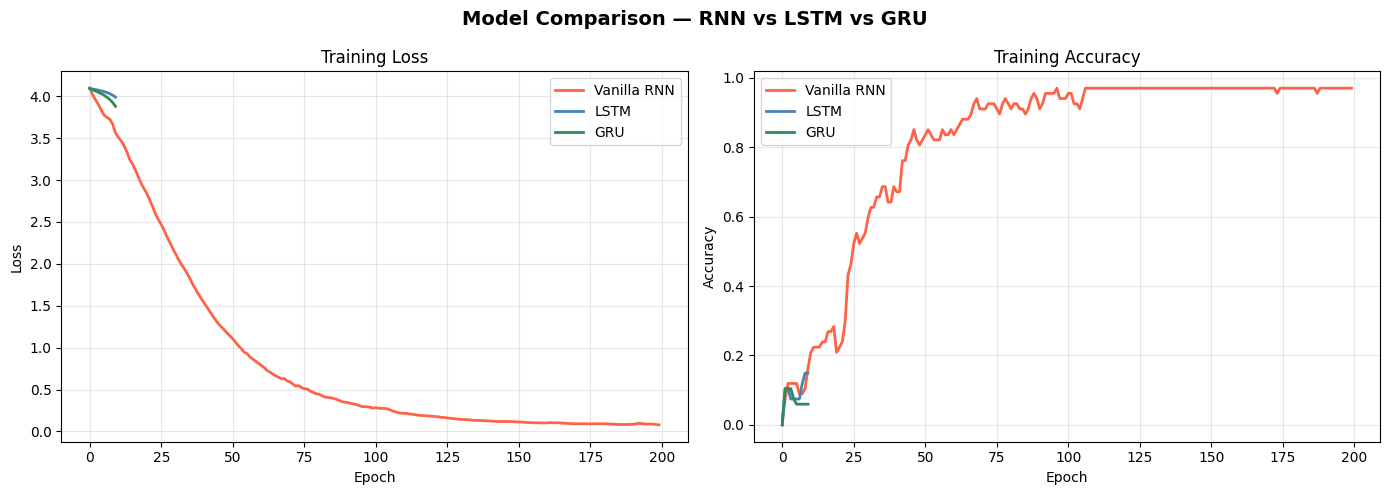

Plot saved as training_comparison.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison — RNN vs LSTM vs GRU', fontsize=14, fontweight='bold')

# ── Loss ──
axes[0].plot(rnn_history.history['loss'],  label='Vanilla RNN', color='tomato',    linewidth=2)
axes[0].plot(lstm_history.history['loss'], label='LSTM',        color='steelblue', linewidth=2)
axes[0].plot(gru_history.history['loss'],  label='GRU',         color='seagreen',  linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Accuracy ──
axes[1].plot(rnn_history.history['accuracy'],  label='Vanilla RNN', color='tomato',    linewidth=2)
axes[1].plot(lstm_history.history['accuracy'], label='LSTM',        color='steelblue', linewidth=2)
axes[1].plot(gru_history.history['accuracy'],  label='GRU',         color='seagreen',  linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as training_comparison.png")

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [15]:
def generate_text(model, seed_text, next_words=5):
    """
    Generate text by predicting one word at a time.

    Args:
        model      : Trained Keras model (RNN / LSTM / GRU)
        seed_text  : Starting phrase (str)
        next_words : Number of words to generate (int)
    Returns:
        Generated sentence (str)
    """
    result = seed_text
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([result])[0]
        token_list = pad_sequences([token_list], maxlen=max_len - 1, padding='pre')
        predicted_idx = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        # Reverse lookup: index → word
        output_word = next(
            (word for word, idx in tokenizer.word_index.items() if idx == predicted_idx),
            "<UNK>"
        )
        result += " " + output_word
    return result

print("generate_text() defined")

generate_text() defined


## 🧪 Generate Text Samples

In [18]:
seed = "deep learning"
n_words = 10

print("=" * 60)
print(f"  Seed phrase : '{seed}'  |  Words to generate: {n_words}")
print("=" * 60)
print(f"Vanilla RNN : {generate_text(rnn_model,  seed, n_words)}")
print(f"LSTM        : {generate_text(lstm_model, seed, n_words)}")
print(f"GRU         : {generate_text(gru_model,  seed, n_words)}")
print("=" * 60)

  Seed phrase : 'deep learning'  |  Words to generate: 10
Vanilla RNN : deep learning is transforming artificial intelligence powers modern applications computers modern learn
LSTM        : deep learning of networks dependencies is is dependencies is require intelligence learning
GRU         : deep learning is learning is of intelligence models lstm of data artificial


In [19]:
seeds = ["recurrent neural", "lstm helps", "gru is"]

for s in seeds:
    print(f"\n🌱 Seed: '{s}'")
    print(f"   RNN  → {generate_text(rnn_model,  s, 5)}")
    print(f"   LSTM → {generate_text(lstm_model, s, 5)}")
    print(f"   GRU  → {generate_text(gru_model,  s, 5)}")


🌱 Seed: 'recurrent neural'
   RNN  → recurrent neural networks process sequential data data
   LSTM → recurrent neural intelligence learning of networks intelligence
   GRU  → recurrent neural is of intelligence models lstm

🌱 Seed: 'lstm helps'
   RNN  → lstm helps solves the vanishing gradient problem
   LSTM → lstm helps learning of networks artificial intelligence
   GRU  → lstm helps learning learning is of intelligence

🌱 Seed: 'gru is'
   RNN  → gru is a simplified version of lstm
   LSTM → gru is learning learning of dependencies computers
   GRU  → gru is learning learning is of intelligence


In [20]:
def count_params(model):
    return model.count_params()

print(f"{'Model':<15} {'Parameters':>12} {'Final Loss':>12} {'Final Acc':>12} {'Epochs Run':>12}")
print("-" * 65)

for name, model, history in [
    ("Vanilla RNN", rnn_model,  rnn_history),
    ("LSTM",        lstm_model, lstm_history),
    ("GRU",         gru_model,  gru_history)
]:
    print(f"{name:<15} "
          f"{count_params(model):>12,} "
          f"{history.history['loss'][-1]:>12.4f} "
          f"{history.history['accuracy'][-1]:>12.4f} "
          f"{len(history.history['loss']):>12}")

Model             Parameters   Final Loss    Final Acc   Epochs Run
-----------------------------------------------------------------
Vanilla RNN           36,284       0.0777       0.9701          200
LSTM                 110,396       3.9896       0.1493           10
GRU                   86,076       3.8795       0.0597           10


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**